# 03 - BuildSafe-AI: Gradient Boosting Models (LightGBM and XGBoost)

**Member:** (write your name and ID here)

**Goal of this notebook:** Train a gradient boosting model to predict the severity class of a DOB ECB violation, and compare it fairly with the other three members' models (Logistic Regression, Linear SVM, Random Forest).

**What I do in this notebook**
1. Load the preprocessed tree data made in Notebook 02
2. Train a baseline LightGBM model
3. Tune it with a time-aware validation set (not random K-fold)
4. Evaluate once on the test set
5. Check the feature importance
6. Run the leakage test (with and without the infraction code columns)
7. Compare with XGBoost
8. Save the model and the results for the team comparison table

## 1. Imports and settings

In [1]:
import sys, subprocess
print("Kernel Python:", sys.executable)
subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm", "xgboost"])

Kernel Python: c:\Users\wenur\AppData\Local\Programs\Python\Python313\python.exe


0

In [2]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.sparse import load_npz
from sklearn.metrics import (f1_score, accuracy_score, recall_score,
                             classification_report, confusion_matrix)
from sklearn.model_selection import ParameterSampler
from sklearn.utils.class_weight import compute_sample_weight
import lightgbm as lgb

warnings.filterwarnings('ignore')

# IMPORTANT: use the same random state as Notebook 02 so all members are comparable
RANDOM_STATE = 42

ARTIFACTS = Path('../../artifacts')
MODELS = Path('../../models')
RESULTS = Path('../../results')      # shared folder for the whole team
MODELS.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)
print('LightGBM version:', lgb.__version__)

LightGBM version: 4.7.0


## 2. Load the data

I use the **tree** version of the data (`X_train_tree.npz`), not the `_linear` one.
The linear version is scaled for Logistic Regression and SVM. Tree models do not need scaling,
so the tree version is the correct one for me.

In [3]:
X_train = load_npz('../../artifacts/X_train_tree.npz').tocsr().astype(np.float32)
X_test  = load_npz('../../artifacts/X_test_tree.npz').tocsr().astype(np.float32)

y_train_raw = pd.read_csv('../../artifacts/y_train.csv').iloc[:, 0]
y_test_raw  = pd.read_csv('../../artifacts/y_test.csv').iloc[:, 0]

feature_names = pd.read_csv('../../artifacts/feature_names_tree.csv').iloc[:, 0].astype(str).tolist()

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('number of feature names:', len(feature_names))
print('labels in y_train:', sorted(y_train_raw.unique()))
assert X_train.shape[0] == len(y_train_raw), 'X_train and y_train rows do not match!'
assert X_test.shape[0] == len(y_test_raw), 'X_test and y_test rows do not match!'
assert X_train.shape[1] == len(feature_names), 'feature names do not match number of columns'

X_train: (81780, 5000)
X_test : (20554, 5000)
number of feature names: 5000
labels in y_train: ['CLASS - 1', 'CLASS - 2', 'CLASS - 3']


## 3. Prepare the labels

LightGBM and XGBoost need the classes as numbers 0, 1, 2. So I map the original labels to numbers
and keep a list of the class names for the reports.

In [4]:
class_names = sorted(y_train_raw.unique())
label_to_id = {c: i for i, c in enumerate(class_names)}
y_train = y_train_raw.map(label_to_id).values
y_test  = y_test_raw.map(label_to_id).values

# Class 1 = Immediately Hazardous. This is the most dangerous class so it is our safety metric.
# CHECK this cell: make sure the label chosen below is really the Class 1 label in your data.
class1_candidates = [c for c in class_names if '1' in str(c)]
CLASS1_LABEL = class1_candidates[0] if class1_candidates else class_names[0]
CLASS1_ID = label_to_id[CLASS1_LABEL]
print('classes:', label_to_id)
print('Class 1 label used for the safety metric:', CLASS1_LABEL, '-> id', CLASS1_ID)

classes: {'CLASS - 1': 0, 'CLASS - 2': 1, 'CLASS - 3': 2}
Class 1 label used for the safety metric: CLASS - 1 -> id 0


## 4. Class imbalance

The classes are not balanced (Class 3 is rare). If I ignore this, the model will just
predict the big classes and ignore the small one, so accuracy would look good but the model
would be bad. I use balanced **sample weights**, which is the same idea as `class_weight='balanced'`
in the other members' models.

In [5]:
counts = pd.Series(y_train_raw).value_counts().sort_index()
print(counts)
print((counts / counts.sum()).round(3))

sample_weight = compute_sample_weight('balanced', y_train)
print('weights per class:', {c: round(float(sample_weight[y_train == label_to_id[c]][0]), 2) for c in class_names})

SEVERITY
CLASS - 1    32140
CLASS - 2    46270
CLASS - 3     3370
Name: count, dtype: int64
SEVERITY
CLASS - 1    0.393
CLASS - 2    0.566
CLASS - 3    0.041
Name: count, dtype: float64
weights per class: {'CLASS - 1': 0.85, 'CLASS - 2': 0.59, 'CLASS - 3': 8.09}


## 5. Helper function for evaluation

All four members must report the same metrics, so I made one function that gives:
accuracy, macro-F1, Class 1 recall and the per-class report. I do not use accuracy as the main metric
because of the imbalance. **Macro-F1** treats every class equally, and **Class 1 recall** tells us how many
of the really dangerous violations we found.

In [6]:
def evaluate(y_true, y_pred, title='Model'):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    class1_recall = recall_score(y_true, y_pred, labels=[CLASS1_ID], average=None)[0]
    print(f'--- {title} ---')
    print(f'Accuracy       : {acc:.4f}')
    print(f'Macro-F1       : {macro_f1:.4f}')
    print(f'Class 1 recall : {class1_recall:.4f}')
    print(classification_report(y_true, y_pred, target_names=[str(c) for c in class_names], digits=3))
    return {'accuracy': acc, 'macro_f1': macro_f1, 'class1_recall': class1_recall}

def plot_confusion(y_true, y_pred, title='Confusion matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(title)
    plt.tight_layout(); plt.show()

## 6. Validation set (time-aware)

The data is time-ordered (the test set is the **newest** violations). So I should not use random
K-fold for tuning, because it would mix future rows into training and give a result that is too optimistic.

Instead I take the **last 20% of the training rows** as a validation set. The model trains on the older
rows and is checked on the newer rows, which copies what happens in real life. The test set stays
untouched until the very end.

> This only works if `train_engineered.csv` is sorted by date. I check this in the next cell.

In [7]:
# Check that the training data is sorted by date (if there is a date column)
try:
    train_eng = pd.read_csv('../artifacts/train_engineered.csv', nrows=None)
    date_cols = [c for c in train_eng.columns if 'DATE' in c.upper()]
    print('date columns found:', date_cols)
    if date_cols:
        d = pd.to_datetime(train_eng[date_cols[0]], errors='coerce')
        print('sorted by date?', d.dropna().is_monotonic_increasing)
    del train_eng
except Exception as e:
    print('could not check the date order:', e)

could not check the date order: [Errno 2] No such file or directory: '../artifacts/train_engineered.csv'


In [8]:
split_point = int(X_train.shape[0] * 0.8)
X_fit, X_val = X_train[:split_point], X_train[split_point:]
y_fit, y_val = y_train[:split_point], y_train[split_point:]
w_fit = sample_weight[:split_point]

print('fit rows       :', X_fit.shape[0])
print('validation rows:', X_val.shape[0])

fit rows       : 65424
validation rows: 16356


## 7. Baseline LightGBM

First I train with simple default-like settings. This baseline is what I compare my tuned model against.
I use **early stopping**: training stops when the validation score does not improve for 30 rounds,
so I do not need to guess the number of trees.

In [9]:
baseline = lgb.LGBMClassifier(
    objective='multiclass',
    n_estimators=500,
    learning_rate=0.1,
    num_leaves=31,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

t0 = time.time()
baseline.fit(X_fit, y_fit, sample_weight=w_fit,
             eval_set=[(X_val, y_val)],
             callbacks=[lgb.early_stopping(30, verbose=False)])
print('training time: %.1f s' % (time.time() - t0))
print('best number of trees:', baseline.best_iteration_)

val_pred = baseline.predict(X_val)
baseline_val = evaluate(y_val, val_pred, 'LightGBM baseline (validation)')

training time: 59.6 s
best number of trees: 500
--- LightGBM baseline (validation) ---
Accuracy       : 0.8463
Macro-F1       : 0.7739
Class 1 recall : 0.8652
              precision    recall  f1-score   support

   CLASS - 1      0.803     0.865     0.833      6076
   CLASS - 2      0.901     0.841     0.870      9745
   CLASS - 3      0.542     0.720     0.618       535

    accuracy                          0.846     16356
   macro avg      0.749     0.809     0.774     16356
weighted avg      0.853     0.846     0.848     16356



## 8. Hyperparameter tuning

I use a **random search** over a small grid of important parameters. Random search is cheaper than a full grid search
and is usually good enough.

| Parameter | What it does | Why I tune it |
|---|---|---|
| `num_leaves` | Size/complexity of each tree | Too big = overfitting |
| `learning_rate` | Step size of each tree | Small = slower but more stable |
| `min_child_samples` | Minimum rows in a leaf | Stops the model learning from tiny groups |
| `colsample_bytree` | Fraction of columns used per tree | Useful because we have thousands of columns |
| `reg_lambda` | L2 regularization | Reduces overfitting |

I choose the best setting by **macro-F1 on the validation set** (not accuracy).

In [10]:
param_grid = {
    'num_leaves':        [15, 31, 63, 127],
    'learning_rate':     [0.03, 0.05, 0.1],
    'min_child_samples': [10, 20, 50, 100],
    'colsample_bytree':  [0.3, 0.5, 0.8],
    'reg_lambda':        [0.0, 1.0, 5.0],
}
N_TRIALS = 8     # increase this if you have time (each trial takes a while)

search_log = []
best_score, best_params, best_trees = -1, None, None

for i, params in enumerate(ParameterSampler(param_grid, n_iter=N_TRIALS, random_state=RANDOM_STATE)):
    model = lgb.LGBMClassifier(objective='multiclass', n_estimators=500,
                               random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **params)
    t0 = time.time()
    model.fit(X_fit, y_fit, sample_weight=w_fit,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(30, verbose=False)])
    pred = model.predict(X_val)
    score = f1_score(y_val, pred, average='macro')
    c1 = recall_score(y_val, pred, labels=[CLASS1_ID], average=None)[0]
    search_log.append({**params, 'trees': model.best_iteration_,
                       'val_macro_f1': round(score, 4), 'val_class1_recall': round(c1, 4),
                       'seconds': round(time.time() - t0, 1)})
    print(f'trial {i+1}/{N_TRIALS}  macro-F1={score:.4f}  class1 recall={c1:.4f}  {params}')
    if score > best_score:
        best_score, best_params, best_trees = score, params, model.best_iteration_

search_df = pd.DataFrame(search_log).sort_values('val_macro_f1', ascending=False)
search_df

trial 1/8  macro-F1=0.7728  class1 recall=0.8611  {'reg_lambda': 1.0, 'num_leaves': 31, 'min_child_samples': 100, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
trial 2/8  macro-F1=0.7584  class1 recall=0.8734  {'reg_lambda': 0.0, 'num_leaves': 31, 'min_child_samples': 50, 'learning_rate': 0.05, 'colsample_bytree': 0.3}
trial 3/8  macro-F1=0.7191  class1 recall=0.8733  {'reg_lambda': 0.0, 'num_leaves': 15, 'min_child_samples': 100, 'learning_rate': 0.03, 'colsample_bytree': 0.5}
trial 4/8  macro-F1=0.7630  class1 recall=0.8680  {'reg_lambda': 0.0, 'num_leaves': 63, 'min_child_samples': 50, 'learning_rate': 0.03, 'colsample_bytree': 0.3}
trial 5/8  macro-F1=0.7826  class1 recall=0.8626  {'reg_lambda': 5.0, 'num_leaves': 63, 'min_child_samples': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
trial 6/8  macro-F1=0.7821  class1 recall=0.8586  {'reg_lambda': 5.0, 'num_leaves': 127, 'min_child_samples': 50, 'learning_rate': 0.1, 'colsample_bytree': 0.5}
trial 7/8  macro-F1=0.7807  class1

,reg_lambda,num_leaves,min_child_samples,learning_rate,colsample_bytree,trees,val_macro_f1,val_class1_recall,seconds
7,1.0,127,10,0.03,0.5,500,0.7829,0.8675,157.8
4,5.0,63,10,0.10,0.8,443,0.7826,0.8626,80.5
5,5.0,127,50,0.10,0.5,203,0.7821,0.8586,63.6
6,0.0,63,50,0.10,0.8,339,0.7807,0.8598,58.9
0,1.0,31,100,0.10,0.8,500,0.7728,0.8611,49.0
3,0.0,63,50,0.03,0.3,500,0.7630,0.8680,47.7
1,0.0,31,50,0.05,0.3,500,0.7584,0.8734,36.3
2,0.0,15,100,0.03,0.5,500,0.7191,0.8733,30.2


In [11]:
print('Best validation macro-F1:', round(best_score, 4))
print('Baseline validation macro-F1:', round(baseline_val['macro_f1'], 4))
print('Best parameters:', best_params)
print('Best number of trees:', best_trees)
search_df.to_csv(RESULTS / 'lightgbm_tuning_log.csv', index=False)

Best validation macro-F1: 0.7829
Baseline validation macro-F1: 0.7739
Best parameters: {'reg_lambda': 1.0, 'num_leaves': 127, 'min_child_samples': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.5}
Best number of trees: 500


## 9. Final model and test set evaluation

Now I train the final model on the **full training set** with the best parameters and the best number of trees,
then evaluate on the test set **one time only**. I do not go back and change the settings after seeing the test result,
because that would be cheating (data leakage from the test set).

--- LightGBM tuned (TEST) ---
Accuracy       : 0.8223
Macro-F1       : 0.7715
Class 1 recall : 0.8738
              precision    recall  f1-score   support

   CLASS - 1      0.784     0.874     0.826      8455
   CLASS - 2      0.880     0.791     0.833     11282
   CLASS - 3      0.597     0.726     0.655       817

    accuracy                          0.822     20554
   macro avg      0.754     0.797     0.772     20554
weighted avg      0.829     0.822     0.823     20554



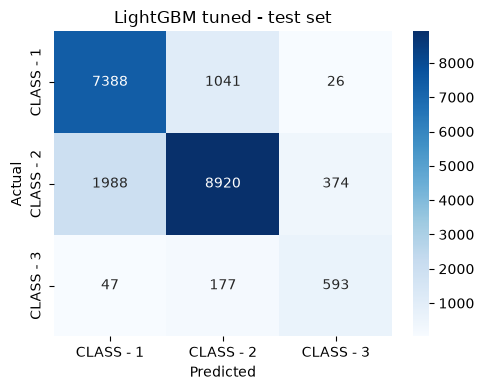

In [12]:
final_model = lgb.LGBMClassifier(objective='multiclass', n_estimators=best_trees,
                                 random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **best_params)
final_model.fit(X_train, y_train, sample_weight=sample_weight)

test_pred = final_model.predict(X_test)
final_scores = evaluate(y_test, test_pred, 'LightGBM tuned (TEST)')
plot_confusion(y_test, test_pred, 'LightGBM tuned - test set')

## 10. Feature importance

This shows which features the model uses the most. I use **gain** (how much each feature improved the model),
which is more meaningful than just counting splits. This also helps me explain the model in the viva.

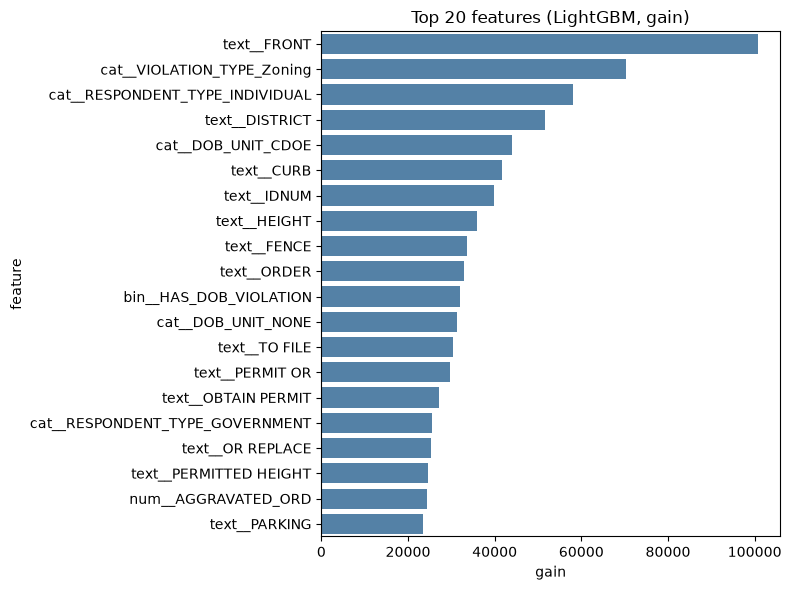

,feature,gain
1860,text__FRONT,100809.677226
4948,cat__VIOLATION_TYPE_Zoning,70260.291371
4951,cat__RESPONDENT_TYPE_INDIVIDUAL,58127.719278
1220,text__DISTRICT,51693.347865
4956,cat__DOB_UNIT_CDOE,44008.195669
1063,text__CURB,41611.545170
2138,text__IDNUM,39892.774309
2052,text__HEIGHT,36027.513991
1659,text__FENCE,33704.589977
3182,text__ORDER,32824.842347


In [13]:
importance = pd.DataFrame({
    'feature': feature_names,
    'gain': final_model.booster_.feature_importance(importance_type='gain'),
}).sort_values('gain', ascending=False)

top = importance.head(20)
plt.figure(figsize=(8, 6))
sns.barplot(data=top, x='gain', y='feature', color='steelblue')
plt.title('Top 20 features (LightGBM, gain)')
plt.tight_layout(); plt.show()
importance.head(20)

## 11. Leakage check: with and without the infraction code columns

In my analysis, `INFRACTION_CODE1` alone predicts the class with about 99.8% macro-F1 because the code
**decides** the class by law. So a model that sees it is just re-discovering a city rule. This is why I train the model again
**without** the columns related to `INFRACTION_CODE1` and `SECTION_LAW_DESCRIPTION1` and compare.

This gives the honest score if the code is not known when we want to make the prediction.

In [14]:
leak_keywords = ['INFRACTION_CODE1', 'SECTION_LAW']
leak_cols = [i for i, name in enumerate(feature_names)
             if any(k in name.upper() for k in leak_keywords)]
keep_cols = [i for i in range(len(feature_names)) if i not in set(leak_cols)]
print('columns related to the code/section:', len(leak_cols))
print('columns kept:', len(keep_cols))

if len(leak_cols) == 0:
    print('No such columns found. Either the code was already removed in Notebook 02 or the names are different.')
    print('Check feature_names_tree.csv by hand.')

columns related to the code/section: 0
columns kept: 5000
No such columns found. Either the code was already removed in Notebook 02 or the names are different.
Check feature_names_tree.csv by hand.


In [15]:
if len(leak_cols) > 0:
    X_train_nc, X_test_nc = X_train[:, keep_cols], X_test[:, keep_cols]
    model_nc = lgb.LGBMClassifier(objective='multiclass', n_estimators=best_trees,
                                  random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **best_params)
    model_nc.fit(X_train_nc, y_train, sample_weight=sample_weight)
    pred_nc = model_nc.predict(X_test_nc)
    scores_nc = evaluate(y_test, pred_nc, 'LightGBM WITHOUT code columns (TEST)')
    plot_confusion(y_test, pred_nc, 'LightGBM without code columns')

    comparison = pd.DataFrame({'with code columns': final_scores,
                               'without code columns': scores_nc}).T.round(4)
    comparison
else:
    scores_nc = None

## 12. XGBoost for comparison

The task says I can use XGBoost **or** LightGBM. I use LightGBM as the main model and XGBoost as a second opinion,
with similar settings, so I can see if the choice of library matters.

In [16]:
try:
    import xgboost as xgb

    xgb_model = xgb.XGBClassifier(
        objective='multi:softprob', n_estimators=500, learning_rate=0.1,
        max_depth=8, subsample=0.8, colsample_bytree=0.5,
        tree_method='hist', eval_metric='mlogloss',
        early_stopping_rounds=30, random_state=RANDOM_STATE, n_jobs=-1)

    t0 = time.time()
    xgb_model.fit(X_fit, y_fit, sample_weight=w_fit,
                  eval_set=[(X_val, y_val)], verbose=False)
    print('XGBoost training time: %.1f s' % (time.time() - t0))
    print('best trees:', xgb_model.best_iteration)

    xgb_pred = xgb_model.predict(X_test)
    xgb_scores = evaluate(y_test, xgb_pred, 'XGBoost (TEST)')
except ImportError:
    print('xgboost is not installed. Run: pip install xgboost')
    xgb_scores = None

XGBoost training time: 441.7 s
best trees: 499
--- XGBoost (TEST) ---
Accuracy       : 0.8057
Macro-F1       : 0.7509
Class 1 recall : 0.8712
              precision    recall  f1-score   support

   CLASS - 1      0.767     0.871     0.816      8455
   CLASS - 2      0.880     0.759     0.815     11282
   CLASS - 3      0.520     0.775     0.622       817

    accuracy                          0.806     20554
   macro avg      0.722     0.802     0.751     20554
weighted avg      0.819     0.806     0.808     20554



## 13. Save the model and the results

The results go into the shared `results/` folder as JSON so Member 1 can build the comparison table
without re-running my notebook.

In [17]:
import joblib
joblib.dump(final_model, MODELS / 'lightgbm_model.joblib')
joblib.dump({'class_names': class_names, 'label_to_id': label_to_id}, MODELS / 'lightgbm_label_map.joblib')

def clean(d):
    return None if d is None else {k: round(float(v), 4) for k, v in d.items()}

per_class = classification_report(y_test, test_pred, target_names=[str(c) for c in class_names],
                                  output_dict=True)

results = {
    'member_model': 'LightGBM',
    'random_state': RANDOM_STATE,
    'features': 'X_*_tree.npz (tree preprocessing)',
    'best_params': best_params,
    'n_trees': int(best_trees),
    'test_with_code_columns': clean(final_scores),
    'test_without_code_columns': clean(scores_nc),
    'xgboost_test_with_code_columns': clean(xgb_scores),
    'per_class_test_with_code_columns': per_class,
}
with open(RESULTS / 'lightgbm.json', 'w') as f:
    json.dump(results, f, indent=2)
print('saved model and results')

saved model and results


## 14. Why did the model do better or worse? (viva notes)

*Fill this in after you see your own results. Use these points as a guide and write them in your own words.*

- **Compared with the baseline:** did tuning improve validation macro-F1? By how much? Was it worth the time?
- **Class 1 recall:** is it high enough for a safety application? What does a missed Class 1 case mean in real life?
- **Rare class (Class 3):** was it harder to predict? Why (few examples, similar words to other classes)?
- **With vs without the code columns:** how big is the drop? What does this say about how much of the score comes from the law rule and not from learning?
- **Compared with the linear models:** the text part is very sparse. Linear models are usually very good on this kind of data,
  so if boosting is not better, it is because the text is already almost linearly separable. If it is better, it is probably because
  of the interactions between the history features and the violation type.
- **Limitations:** the model is trained on past data only, and the rules or inspector writing style can change over time.